In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('Churn_Modelling.csv')

print(f"Размер детасета: {df.shape} клиентов и {df.shape[1]} признаков")
print(df.columns)
df.info()
df = df.drop(['RowNumber', 'CustomerID', 'Surname'], axis=1)

economic_stats = df.groupby('Gender')[['Balance', 'EstimatedSalary']].mean()
print('\nСредний баланс и зарплата по полу\n', economic_stats)

print('\nПервые 3 строки данных')
df.head(3)

Размер детасета: (10000, 14) клиентов и 14 признаков
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 no

KeyError: "['CustomerID'] not found in axis"

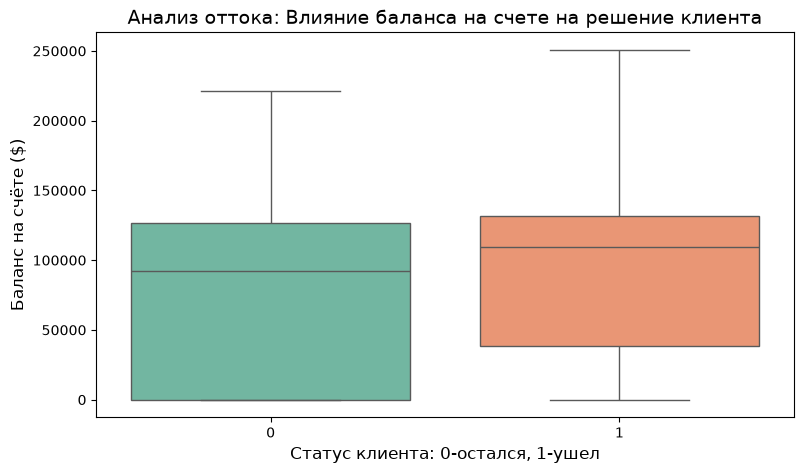

In [ ]:
plt.figure(figsize=(9,5))

sns.boxplot(x="Exited", y="Balance", data=df, palette="Set2", legend=False, hue="Exited")

plt.title("Анализ оттока: Влияние баланса на счете на решение клиента", fontsize=14)
plt.xlabel("Статус клиента: 0-остался, 1-ушел",fontsize=12)
plt.ylabel("Баланс на счёте ($)", fontsize=12)
plt.show()

In [27]:
y = df["Exited"]
X = pd.get_dummies(df.drop("Exited", axis=1), columns=["Geography", "Gender"], drop_first=True)

print("Даныне после обработки категоральных признаков")
X.head(3)

Даныне после обработки категоральных признаков


,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,False,False,False


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.2, random_state=42, stratify=y
)

numeric_cols=[
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
]
scaler=StandardScaler()
X_train[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=scaler.transform(X_test[numeric_cols])
X_train.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
7839,7840,15606003,Abramowitz,-0.883318,-1.694908,-0.695694,-1.237715,0.760806,1,1,-1.698291,False,False,False
9106,9107,15663650,Russell,0.480544,1.242870,1.775687,0.496707,2.442147,1,0,-1.260670,True,False,True
3391,3392,15780411,Norris,-0.841989,0.674267,-0.695694,-1.237715,0.760806,0,0,-1.747058,False,False,False


Обучение модели и Оценка экономического эффекта

In [ ]:
model=RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)

accuracy=accuracy_score(y_test, y_pred) * 100

print(f"Общая точность модели (Accuracy): {accuracy:.2f}%\n")